# RNN Day 1 Housing Data

### Importing Libraries

In [1]:
import pandas as pd                                 # table/dataframe handling
import numpy as np                                  # numerical operations
import matplotlib.pyplot as plt                     # plotting

from sklearn.preprocessing import MinMaxScaler      # scales values to 0-1 range
from sklearn.metrics import mean_absolute_error, mean_squared_error
                                                    # RMSE and MAE calculation

import tensorflow as tf
import random

from tensorflow.keras.models import Sequential      # sequential neural network API

from tensorflow.keras.layers import (
    Dense,                                          # standard fully connected layer
    SimpleRNN,                                      # recurrent neural network layer
    Conv1D,                                         # 1D convolution layer
    Flatten                                         # flatten multidimensional output
)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### Loading the data

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
house = pd.read_csv("/content/ma_lga_12345.csv")   # load housing dataset

house.head()                              # ma_lga_12345.csvinspect first few rows

,saledate,MA,type,bedrooms
0,30/09/2007,441854,house,2
1,31/12/2007,441854,house,2
2,31/03/2008,441854,house,2
3,30/06/2008,441854,house,2
4,30/09/2008,451583,house,2


### Inspecting the temporal nature of the data

In [3]:
print(house.shape)            # number of rows and columns
print(house.dtypes)           # variable data types
print(house.isna().sum())     # missing values per column

house.describe()              # summary statistics

(347, 4)
saledate    object
MA           int64
type        object
bedrooms     int64
dtype: object
saledate    0
MA          0
type        0
bedrooms    0
dtype: int64


,MA,bedrooms
count,3.470000e+02,347.000000
mean,5.481320e+05,2.867435
std,1.701934e+05,1.239875
min,3.167510e+05,1.000000
25%,4.277395e+05,2.000000
50%,5.077440e+05,3.000000
75%,6.275155e+05,4.000000
max,1.017752e+06,5.000000


## Defining useful functions


Formatting data for rolling windows

In [4]:
def create_sequences(dataset, look_back=2):

    X, y = [], []                          # containers for windows and targets

    for i in range(len(dataset) - look_back):

        X.append(dataset[i:i + look_back, :])   # rolling window
        y.append(dataset[i + look_back, 0])     # next timestep target

    return np.array(X), np.array(y)

Plotting training curves

In [5]:
def plot_training_curves(history, title):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["loss"], label="Training Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_title(title + " Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")
    axes[0].set_ylim(0, 0.4)
    axes[0].legend()

    axes[1].plot(history.history["mean_absolute_error"], label="Training MAE")
    axes[1].plot(history.history["val_mean_absolute_error"], label="Validation MAE")
    axes[1].set_title(title + " MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Mean Absolute Error")
    axes[1].set_ylim(0, 0.65)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Evaluating model performance on test data

In [6]:
def evaluate_and_plot(model, trainX, testX, trainY, testY, scaler, title):

    # Make predictions
    train_pred = model.predict(trainX)
    test_pred = model.predict(testX)

    # Convert scaled values back to original MA scale
    train_pred_inv = scaler.inverse_transform(train_pred)
    test_pred_inv = scaler.inverse_transform(test_pred)
    trainY_inv = scaler.inverse_transform(trainY.reshape(-1, 1))
    testY_inv = scaler.inverse_transform(testY.reshape(-1, 1))

    # Calculate RMSE on original scale
    train_rmse = np.sqrt(mean_squared_error(trainY_inv, train_pred_inv))
    test_rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))

    print(f"{title} Train RMSE: {train_rmse:.2f}")
    print(f"{title} Test RMSE: {test_rmse:.2f}")

    # Plot held-out future test predictions
    plt.figure(figsize=(10, 4))
    plt.plot(testY_inv, label="Actual")
    plt.plot(test_pred_inv, label="Predicted")

    plt.title(title + " Test Predictions")
    plt.xlabel("Test time index")
    plt.ylabel("MA")
    plt.ylim(0, 1200000)
    plt.ticklabel_format(style="plain", axis="y")
    plt.legend()
    plt.show()

Comparing forcasting performance metrics

In [7]:

def evaluate_metrics(model, testX, testY, scaler):

    test_pred = model.predict(testX)

    test_pred_inv = scaler.inverse_transform(test_pred)
    testY_inv = scaler.inverse_transform(testY.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    mae = mean_absolute_error(testY_inv, test_pred_inv)

    return rmse, mae

### Initial RNN & Performance

In [8]:
# Initial RNN

ma_sequence = house.copy()
ma_sequence = ma_sequence.sort_values("saledate").reset_index(drop=True)
                                                                # preserve chronological order

df_initial = ma_sequence[["MA"]].copy()                         # univariate forecasting feature

scaler_initial = MinMaxScaler(feature_range=(0, 1))
scaled_initial = scaler_initial.fit_transform(df_initial)
                                                                # neural networks train better on scaled values

look_back = 2                                                   # use previous 2 timesteps to predict next timestep

train_size = int(len(scaled_initial) * 0.8)

train_initial = scaled_initial[:train_size]                     # earlier historical data
test_initial = scaled_initial[train_size:]                      # held-out future data

trainX_initial, trainY_initial = create_sequences(
    train_initial,
    look_back
)                                                               # rolling training windows

testX_initial, testY_initial = create_sequences(
    test_initial,
    look_back
)                                                               # rolling future test windows

print("trainX shape:", trainX_initial.shape)
print("testX shape:", testX_initial.shape)

initial_model = Sequential([
    SimpleRNN(
        16,
        activation="tanh",
        input_shape=(look_back, trainX_initial.shape[2])
    ),                                                          # recurrent hidden layer

    Dense(1)                                                    # regression output layer
])

initial_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

initial_history = initial_model.fit(
    trainX_initial,
    trainY_initial,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,                                              # preserve temporal order
    verbose=1
)

trainX shape: (275, 2, 1)
testX shape: (68, 2, 1)
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1027 - mean_absolute_error: 0.2647 - val_loss: 0.0916 - val_mean_absolute_error: 0.2549
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0868 - mean_absolute_error: 0.2409 - val_loss: 0.0807 - val_mean_absolute_error: 0.2324
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0758 - mean_absolute_error: 0.2230 - val_loss: 0.0740 - val_mean_absolute_error: 0.2187
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0682 - mean_absolute_error: 0.2089 - val_loss: 0.0702 - val_mean_absolute_error: 0.2103
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0633 - mean_absolute_error: 0.1992 - val_loss: 0.0686 - val_mean_absolute_error: 0.2046
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0602 - mean_absolute_error: 0.1938 - val_loss: 0.0682 - val_mean_absolute_error: 0.2039
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0583 - mean_absolute_error: 0.1910 - val_loss: 0.0685 - 

Training curves

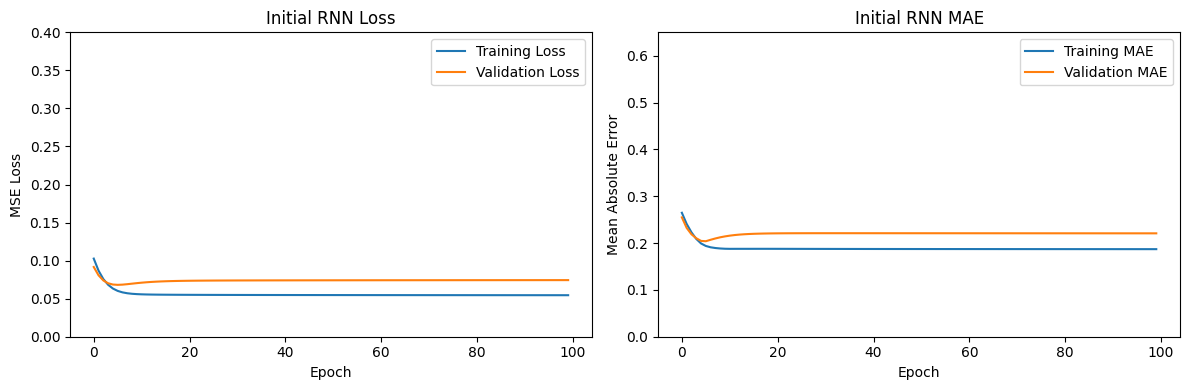

In [9]:
plot_training_curves(
    initial_history,
    "Initial RNN"
)

Test data evaluation

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Initial RNN Train RMSE: 168752.01
Initial RNN Test RMSE: 171397.52


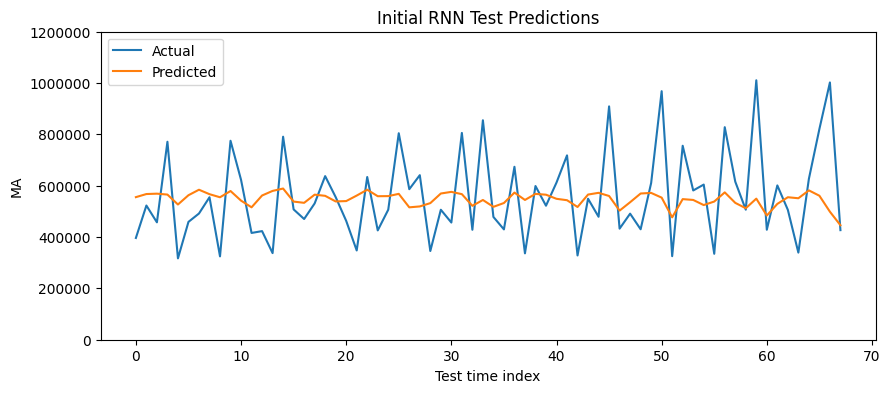

In [10]:
evaluate_and_plot(
    initial_model,
    trainX_initial,
    testX_initial,
    trainY_initial,
    testY_initial,
    scaler_initial,
    "Initial RNN"
)

### Initial MA data re-evaluation

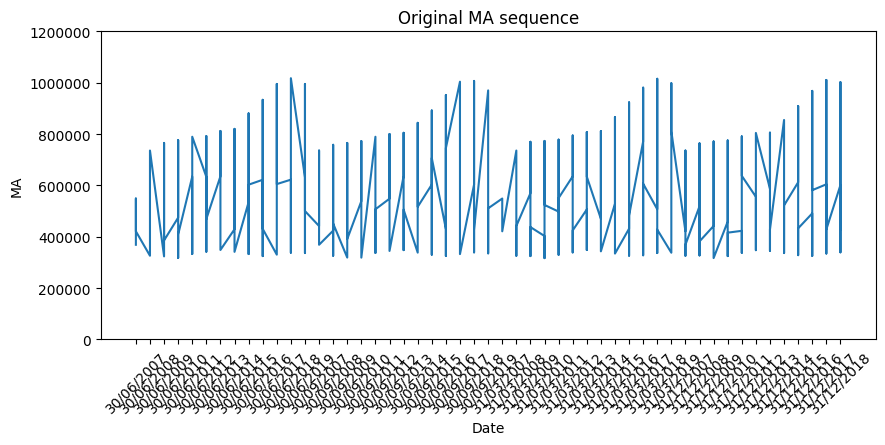

In [11]:
# Plot the original MA sequence exactly as provided

plt.figure(figsize=(10, 4))

plt.plot(
    ma_sequence["saledate"],
    ma_sequence["MA"]
)

plt.title("Original MA sequence")
plt.xlabel("Date")
plt.ylabel("MA")

plt.ylim(0, 1200000)

plt.ticklabel_format(
    style='plain',
    axis='y'
)

plt.xticks(rotation=45)

plt.show()


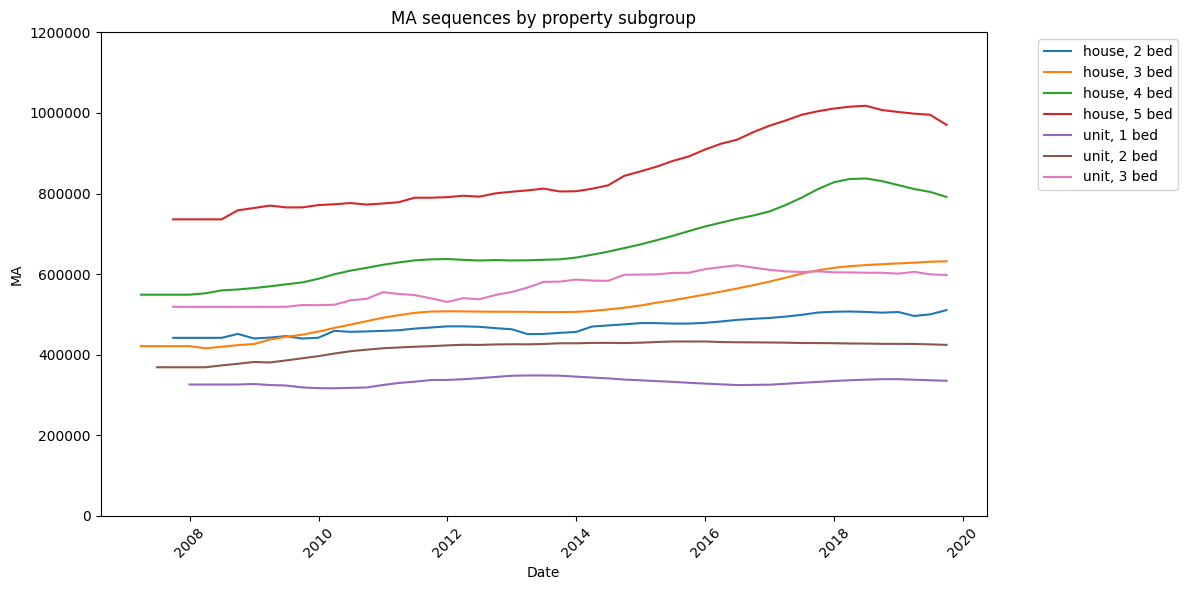

In [12]:
# Plot each subgroup MA sequence separately

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)

# Plot each subgroup MA sequence separately

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)

plt.figure(figsize=(12, 6))

for (property_type, bedrooms), group in house.groupby(["type", "bedrooms"]):

    group = group.sort_values("saledate")      # chronological ordering

    plt.plot(
        group["saledate"],
        group["MA"],
        label=f"{property_type}, {bedrooms} bed"
    )

plt.title("MA sequences by property subgroup")

plt.xlabel("Date")
plt.ylabel("MA")

plt.ylim(0, 1200000)

plt.ticklabel_format(
    style='plain',
    axis='y'
)

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

Inspecting the first window

In [13]:
print("trainX_initial shape:", trainX_initial.shape)

window_id = 0

ma_sequence.iloc[
    window_id : window_id + look_back + 1
][["saledate", "type", "bedrooms", "MA"]]

trainX_initial shape: (275, 2, 1)


,saledate,type,bedrooms,MA
0,30/06/2007,unit,2,368817
1,30/06/2007,house,4,548969
2,30/06/2007,house,3,421291


### Creating market-level MA data

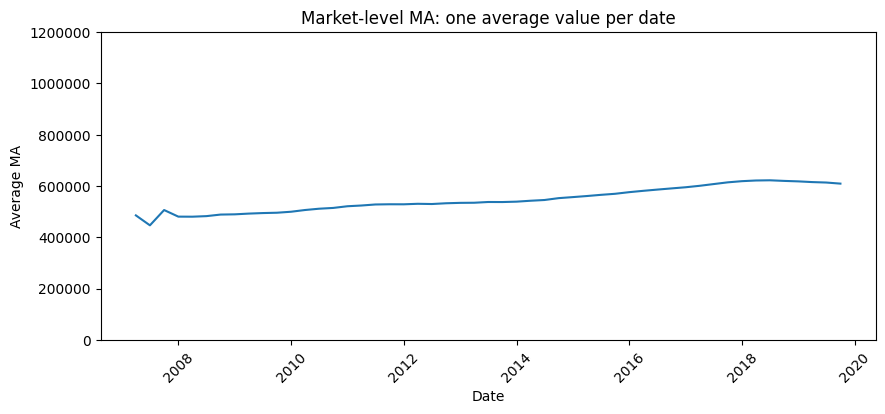

In [14]:
# Create market-level MA sequence

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)                                                    # ensure dates sort chronologically

market_ma = (
    house
    .groupby("saledate")["MA"]
    .mean()
    .reset_index()
    .sort_values("saledate")
    .reset_index(drop=True)
)                                                    # average subgroup MAs per date

# Visualize market-level MA

plt.figure(figsize=(10, 4))

plt.plot(
    market_ma["saledate"],
    market_ma["MA"]
)

plt.title("Market-level MA: one average value per date")
plt.xlabel("Date")
plt.ylabel("Average MA")

plt.ylim(0, 1200000)
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)

plt.show()

### Preparing market-level MA data for variety of models

In [15]:
# Prepare market-level MA data for all fixed-data models

df_market = market_ma[["MA"]].copy()                            # cleaned one-value-per-date MA series

scaler_market = MinMaxScaler(feature_range=(0, 1))              # scale MA values for neural networks
scaled_market = scaler_market.fit_transform(df_market)

look_back = 2                                                   # use 2 previous timesteps to predict next timestep

train_size = int(len(scaled_market) * 0.8)                      # chronological 80/20 split

train_market = scaled_market[:train_size]                       # earlier historical data
test_market = scaled_market[train_size:]                        # held-out future data

trainX_market, trainY_market = create_sequences(
    train_market,
    look_back
)                                                               # sequence windows for RNN/CNN

testX_market, testY_market = create_sequences(
    test_market,
    look_back
)                                                               # future test windows for RNN/CNN

trainX_market_mlp = trainX_market.reshape(
    trainX_market.shape[0],
    trainX_market.shape[1] * trainX_market.shape[2]
)                                                               # flattened windows for MLP

testX_market_mlp = testX_market.reshape(
    testX_market.shape[0],
    testX_market.shape[1] * testX_market.shape[2]
)                                                               # flattened test windows for MLP

print("RNN/CNN trainX_market shape:", trainX_market.shape)
print("RNN/CNN testX_market shape:", testX_market.shape)

print("MLP trainX_market_mlp shape:", trainX_market_mlp.shape)
print("MLP testX_market_mlp shape:", testX_market_mlp.shape)

RNN/CNN trainX_market shape: (38, 2, 1)
RNN/CNN testX_market shape: (9, 2, 1)
MLP trainX_market_mlp shape: (38, 2)
MLP testX_market_mlp shape: (9, 2)


### Inspecting the tensors

Shape & window 0 values

In [16]:
print("trainX_market shape:", trainX_market.shape)

window_id = 0

market_ma.iloc[
    window_id : window_id + look_back + 1
][["saledate", "MA"]]

trainX_market shape: (38, 2, 1)


,saledate,MA
0,2007-03-31,485130.000000
1,2007-06-30,446359.000000
2,2007-09-30,505957.666667


Scale window 0

In [17]:
# Visualize one input window and its target

window_id = 0

print("Input window:")
print(trainX_market[window_id].flatten())

print("Target:")
print(trainY_market[window_id])

Input window:
[0.22095731 0.        ]
Target:
0.33965492068299463


### Market-level RNN model & evaluation

In [18]:
# Build and train market-level RNN model

market_rnn_model = Sequential([
    SimpleRNN(
        16,
        activation="tanh",
        input_shape=(look_back, trainX_market.shape[2])
    ),
    Dense(1)
])

market_rnn_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_rnn_history = market_rnn_model.fit(
    trainX_market,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - loss: 0.0500 - mean_absolute_error: 0.2169 - val_loss: 0.1204 - val_mean_absolute_error: 0.3453
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0223 - mean_absolute_error: 0.1427 - val_loss: 0.0597 - val_mean_absolute_error: 0.2425
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0068 - mean_absolute_error: 0.0768 - val_loss: 0.0229 - val_mean_absolute_error: 0.1492
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0017 - mean_absolute_error: 0.0272 - val_loss: 0.0061 - val_mean_absolute_error: 0.0754
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0028 - mean_absolute_error: 0.0423 - val_loss: 0.0013 - val_mean_absolute_error: 0.0306
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0049 - mean_absolute_error: 0.0608 - val_loss: 6.6129e-04 - val_mean_absolute_error: 0.0215
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052 - mean_absolute_error: 0.0612 - val_loss: 0.0013 - val

Training curves

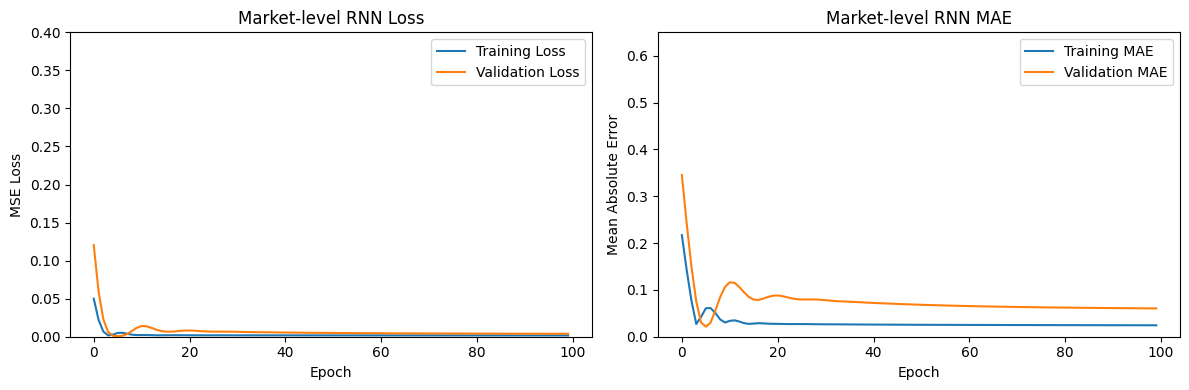

In [19]:
plot_training_curves(
    market_rnn_history,
    "Market-level RNN"
)

Test data evaluation

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Market-level RNN Train RMSE: 8131.16
Market-level RNN Test RMSE: 15985.00


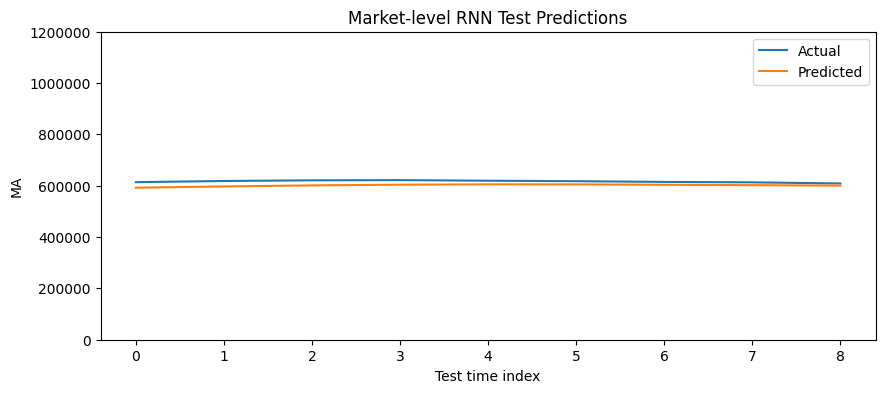

In [20]:
evaluate_and_plot(
    market_rnn_model,
    trainX_market,
    testX_market,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level RNN"
)

### Market level MLP and evaluation

In [21]:
# Build and train market-level MLP model

market_mlp_model = Sequential([
    Dense(
        32,
        activation="relu",
        input_shape=(trainX_market_mlp.shape[1],)
    ),
    Dense(
        16,
        activation="relu"
    ),
    Dense(1)
])

market_mlp_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_mlp_history = market_mlp_model.fit(
    trainX_market_mlp,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0963 - mean_absolute_error: 0.2989 - val_loss: 0.2720 - val_mean_absolute_error: 0.5195
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0762 - mean_absolute_error: 0.2646 - val_loss: 0.2254 - val_mean_absolute_error: 0.4728
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0604 - mean_absolute_error: 0.2341 - val_loss: 0.1870 - val_mean_absolute_error: 0.4305
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0456 - mean_absolute_error: 0.2016 - val_loss: 0.1498 - val_mean_absolute_error: 0.3851
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0322 - mean_absolute_error: 0.1670 - val_loss: 0.1146 - val_mean_absolute_error: 0.3366
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0213 - mean_absolute_error: 0.1330 - val_loss: 0.0845 - val_mean_absolute_error: 0.2888
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0130 - mean_absolute_error: 0.1011 - val_loss: 0.0601 - val_mean

Training curves MLP

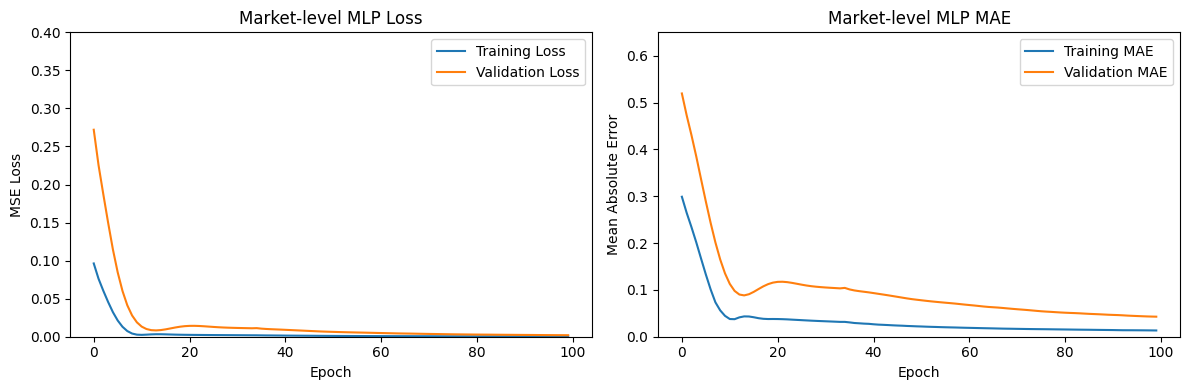

In [22]:
plot_training_curves(
    market_mlp_history,
    "Market-level MLP"
)

Test data evaluation MLP

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Market-level MLP Train RMSE: 4631.41
Market-level MLP Test RMSE: 10526.73


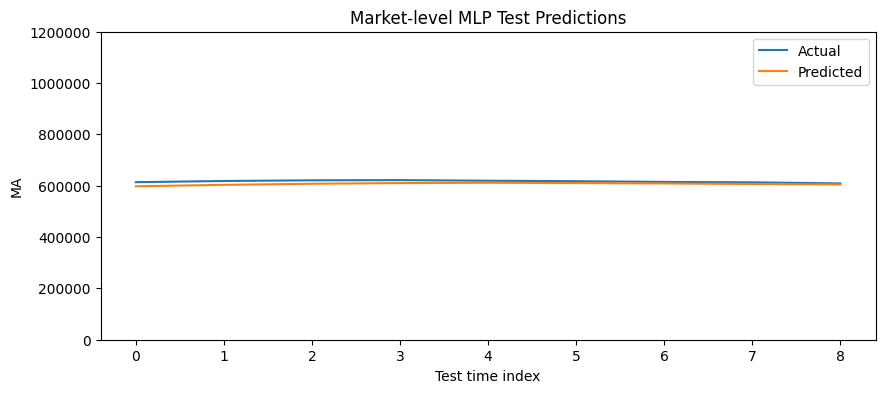

In [23]:
evaluate_and_plot(
    market_mlp_model,
    trainX_market_mlp,
    testX_market_mlp,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level MLP"
)

### Market level CNN & evaluation

In [24]:
# Build and train market-level 1D CNN model

market_cnn_model = Sequential([
    Conv1D(
        filters=16,                         # learn 16 temporal pattern detectors
        kernel_size=2,                      # each filter looks across 2 neighboring timesteps
        activation="relu",
        input_shape=(look_back, trainX_market.shape[2])
    ),                                      # input shape = timesteps, features

    Flatten(),                              # convert CNN output to flat vector for Dense layer

    Dense(1)                                # regression output layer
])

market_cnn_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_cnn_history = market_cnn_model.fit(
    trainX_market,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,                          # preserve temporal order
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0999 - mean_absolute_error: 0.3029 - val_loss: 0.2975 - val_mean_absolute_error: 0.5433
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0884 - mean_absolute_error: 0.2840 - val_loss: 0.2710 - val_mean_absolute_error: 0.5184
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0778 - mean_absolute_error: 0.2656 - val_loss: 0.2458 - val_mean_absolute_error: 0.4937
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0681 - mean_absolute_error: 0.2474 - val_loss: 0.2222 - val_mean_absolute_error: 0.4693
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0592 - mean_absolute_error: 0.2297 - val_loss: 0.2003 - val_mean_absolute_error: 0.4455
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0514 - mean_absolute_error: 0.2127 - val_loss: 0.1801 - val_mean_absolute_error: 0.4224
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0445 - mean_absolute_error: 0.1967 - val_loss: 0.1618 - val_mean

Training curves 1D CNN

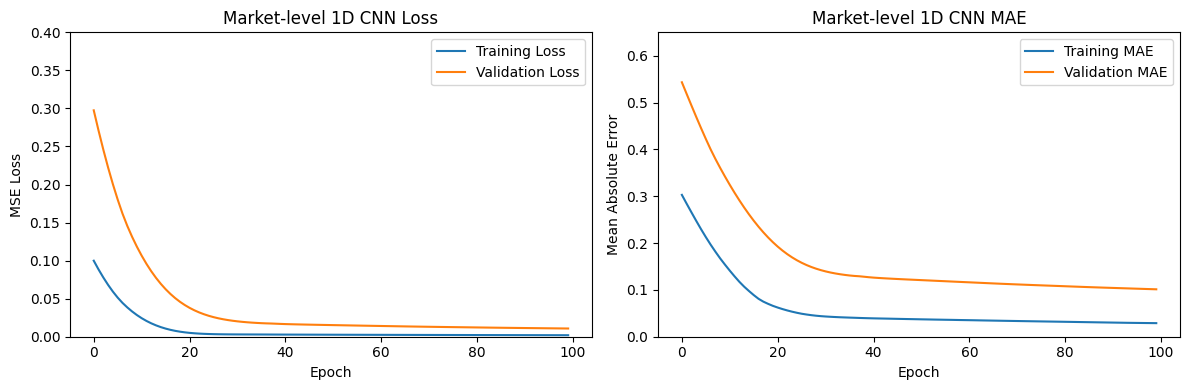

In [25]:
plot_training_curves(
    market_cnn_history,
    "Market-level 1D CNN"
)

Test data evaluation 1D CNN

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Market-level 1D CNN Train RMSE: 10858.95
Market-level 1D CNN Test RMSE: 27010.29


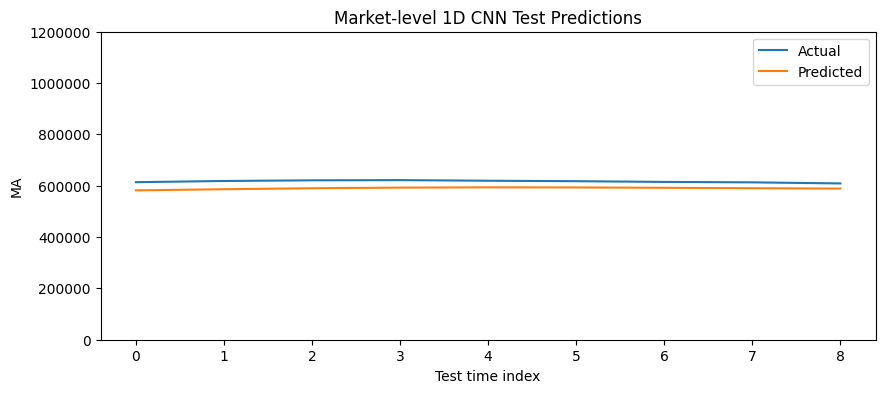

In [26]:
evaluate_and_plot(
    market_cnn_model,
    trainX_market,
    testX_market,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level 1D CNN"
)

### Comparison of RNN vs MLP vs 1D CNN

In [27]:
rnn_rmse, rnn_mae = evaluate_metrics(
    market_rnn_model,
    testX_market,
    testY_market,
    scaler_market
)

mlp_rmse, mlp_mae = evaluate_metrics(
    market_mlp_model,
    testX_market_mlp,
    testY_market,
    scaler_market
)

cnn_rmse, cnn_mae = evaluate_metrics(
    market_cnn_model,
    testX_market,
    testY_market,
    scaler_market
)

comparison = pd.DataFrame({
    "Model": ["RNN", "MLP", "1D CNN"],
    "RMSE": [rnn_rmse, mlp_rmse, cnn_rmse],
    "MAE": [rnn_mae, mlp_mae, cnn_mae]
})

comparison

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


,Model,RMSE,MAE
0,RNN,15985.004700,15295.120040
1,MLP,10526.726267,9675.571429
2,1D CNN,27010.286225,26676.696429


### Your Turn — Build and Compare RNN Models

Choose one or more coherent housing subgroups (for example, 3-bedroom houses) and build at least 3 meaningfully different RNN forecasting models. Evaluate each model using training/validation curves, held-out future test predictions, RMSE, and MAE, and record your observations in markdown cells throughout the notebook.

### Model Exploration Summary

Briefly summarize which subgroup(s) and model variations you explored, what changes appeared to improve or worsen forecasting performance, any patterns you noticed in the training curves or predictions, and which model you believe performed best and why.

Subgroup rows: 39
Date range: 2010-03-31 to 2019-09-30


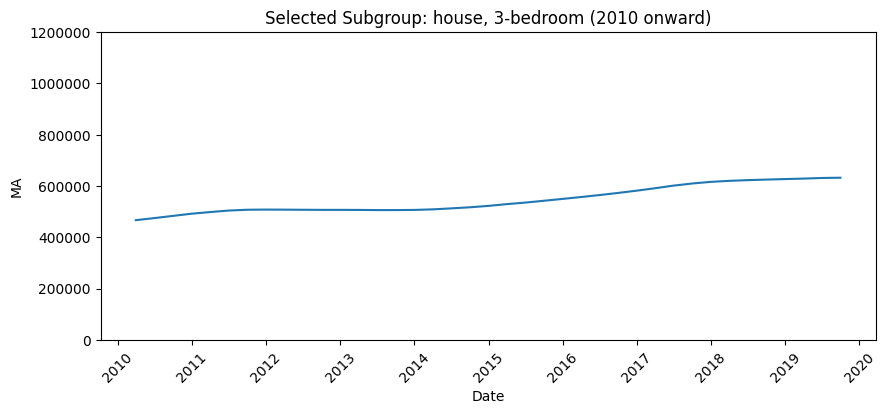

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RNN_A_baseline trained | look_back=2 | units=[16] | lr=0.001
RNN_B_longer_window trained | look_back=4 | units=[16] | lr=0.001
RNN_C_stacked trained | look_back=4 | units=[32, 16] | lr=0.0007


In [28]:
# Your code here
# Subgroup + different time period + 3 RNN configurations

from tensorflow.keras.callbacks import EarlyStopping

# use one coherent subgroup and a later time period
subgroup = house[(house["type"] == "house") & (house["bedrooms"] == 3)].copy()
subgroup["saledate"] = pd.to_datetime(subgroup["saledate"], dayfirst=True)
subgroup = subgroup.sort_values("saledate")
subgroup = subgroup[subgroup["saledate"] >= "2010-01-01"].reset_index(drop=True)

print("Subgroup rows:", len(subgroup))
print("Date range:", subgroup["saledate"].min().date(), "to", subgroup["saledate"].max().date())

# quick plot of chosen subgroup/time period
plt.figure(figsize=(10, 4))
plt.plot(subgroup["saledate"], subgroup["MA"])
plt.title("Selected Subgroup: house, 3-bedroom (2010 onward)")
plt.xlabel("Date")
plt.ylabel("MA")
plt.ylim(0, 1200000)
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)
plt.show()

# scale + chronological split
df_sub = subgroup[["MA"]].copy()
scaler_sub = MinMaxScaler(feature_range=(0, 1))
scaled_sub = scaler_sub.fit_transform(df_sub)

train_size_sub = int(len(scaled_sub) * 0.8)
train_sub = scaled_sub[:train_size_sub]
test_sub = scaled_sub[train_size_sub:]

# 3 meaningfully different RNN configs
# Config B changes only look_back from A (one-factor-at-a-time)
rnn_configs = [
    {"name": "RNN_A_baseline", "look_back": 2, "units": [16], "lr": 0.0010, "batch": 8, "epochs": 150},
    {"name": "RNN_B_longer_window", "look_back": 4, "units": [16], "lr": 0.0010, "batch": 8, "epochs": 150},
    {"name": "RNN_C_stacked", "look_back": 4, "units": [32, 16], "lr": 0.0007, "batch": 8, "epochs": 180},
]

rnn_runs = {}

for cfg in rnn_configs:
    look_back_sub = cfg["look_back"]

    trainX_sub, trainY_sub = create_sequences(train_sub, look_back_sub)
    testX_sub, testY_sub = create_sequences(test_sub, look_back_sub)

    model = Sequential()

    if len(cfg["units"]) == 1:
        model.add(
            SimpleRNN(
                cfg["units"][0],
                activation="tanh",
                input_shape=(look_back_sub, trainX_sub.shape[2])
            )
        )
    else:
        model.add(
            SimpleRNN(
                cfg["units"][0],
                activation="tanh",
                return_sequences=True,
                input_shape=(look_back_sub, trainX_sub.shape[2])
            )
        )
        model.add(SimpleRNN(cfg["units"][1], activation="tanh"))

    model.add(Dense(1))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg["lr"]),
        loss="mean_squared_error",
        metrics=["mean_absolute_error"]
    )

    early_stop_sub = EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True
    )

    history = model.fit(
        trainX_sub,
        trainY_sub,
        epochs=cfg["epochs"],
        batch_size=cfg["batch"],
        validation_split=0.2,
        shuffle=False,
        callbacks=[early_stop_sub],
        verbose=0
    )

    rnn_runs[cfg["name"]] = {
        "config": cfg,
        "model": model,
        "history": history,
        "trainX": trainX_sub,
        "trainY": trainY_sub,
        "testX": testX_sub,
        "testY": testY_sub
    }

    print(f"{cfg['name']} trained | look_back={cfg['look_back']} | units={cfg['units']} | lr={cfg['lr']}")


RNN_A_baseline
{'name': 'RNN_A_baseline', 'look_back': 2, 'units': [16], 'lr': 0.001, 'batch': 8, 'epochs': 150}


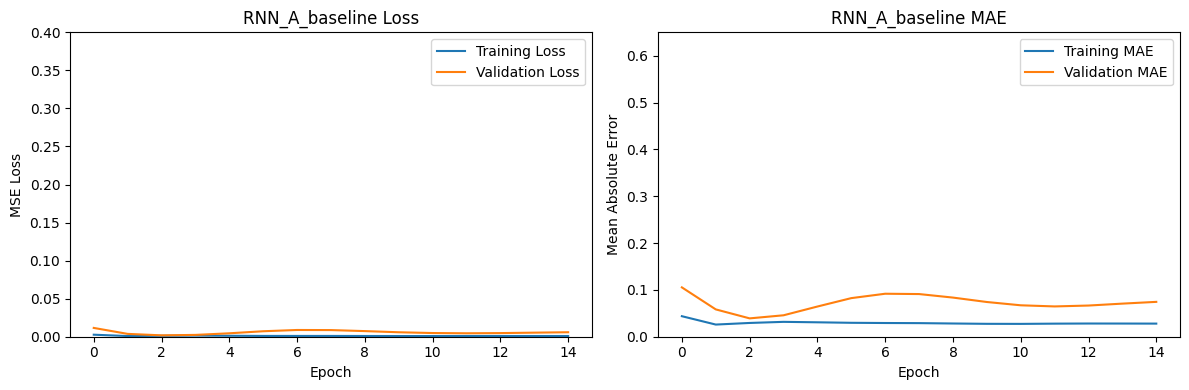

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
RNN_A_baseline Train RMSE: 6505.60
RNN_A_baseline Test RMSE: 6554.72


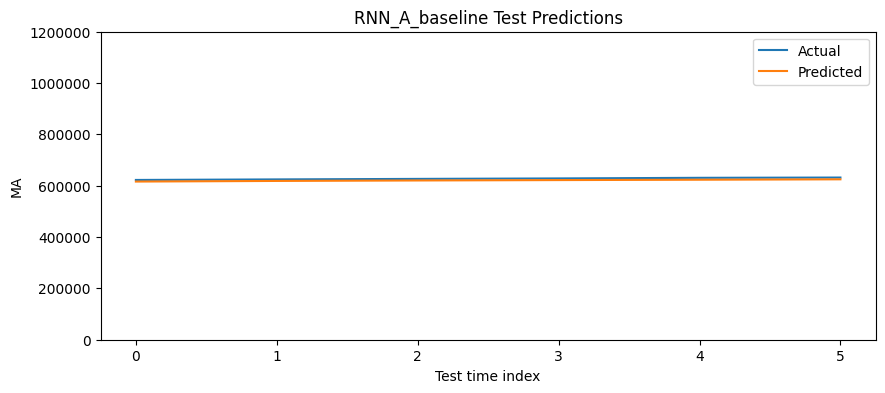

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

RNN_B_longer_window
{'name': 'RNN_B_longer_window', 'look_back': 4, 'units': [16], 'lr': 0.001, 'batch': 8, 'epochs': 150}


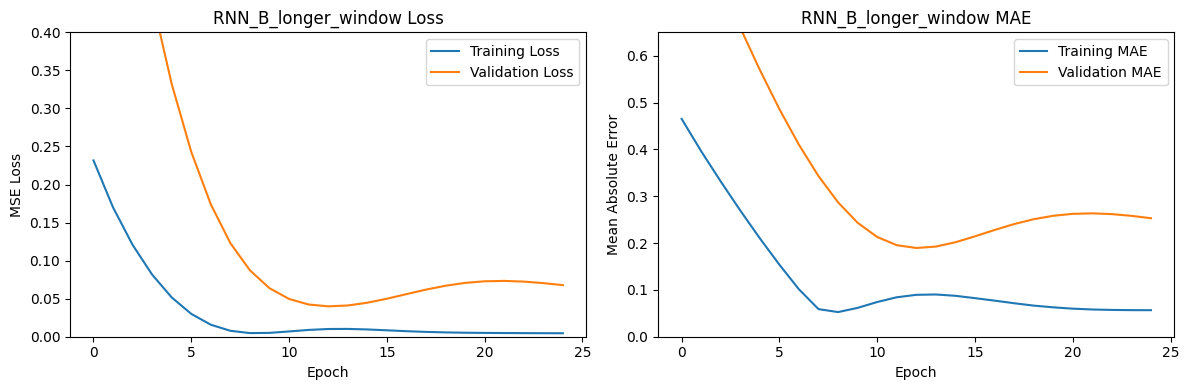

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
RNN_B_longer_window Train RMSE: 21499.12
RNN_B_longer_window Test RMSE: 54923.81


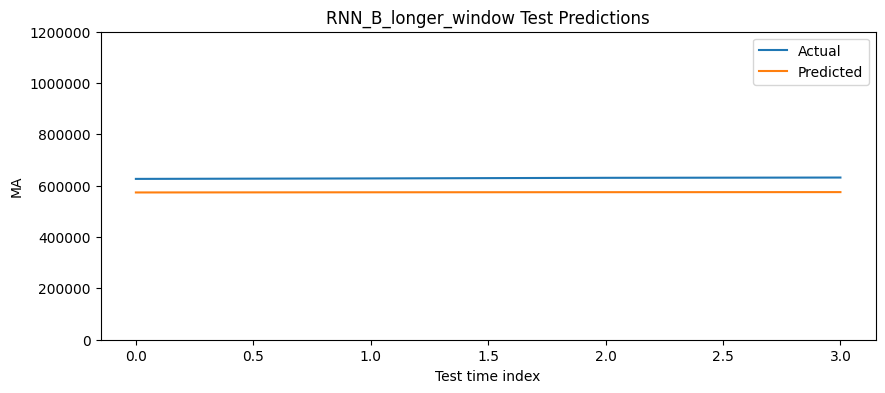

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

RNN_C_stacked
{'name': 'RNN_C_stacked', 'look_back': 4, 'units': [32, 16], 'lr': 0.0007, 'batch': 8, 'epochs': 180}


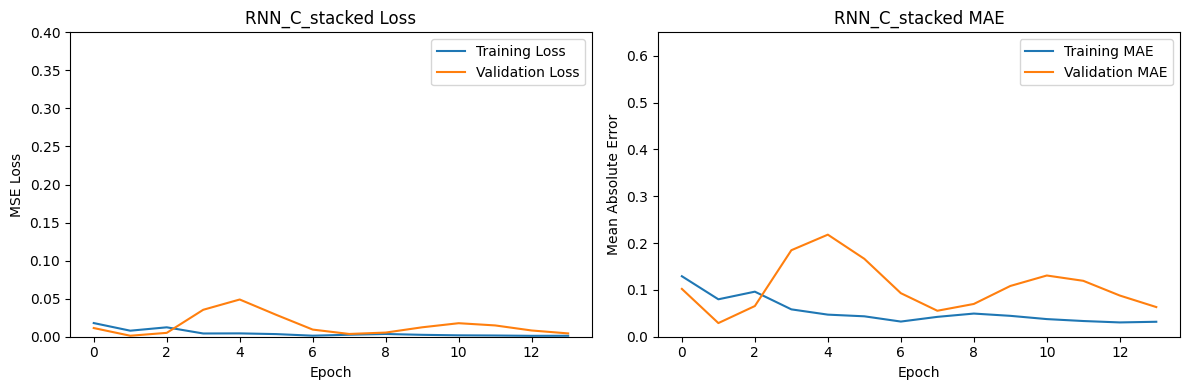

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
RNN_C_stacked Train RMSE: 17794.11
RNN_C_stacked Test RMSE: 2113.33


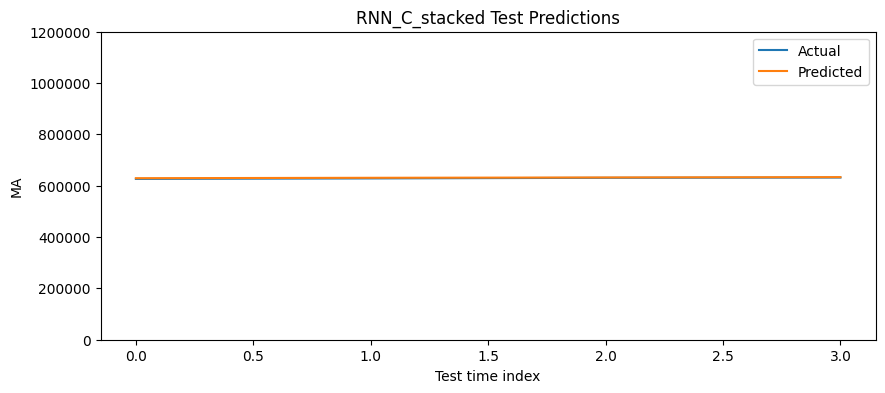

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


,Model,Look_Back,Units,Learning_Rate,Batch_Size,Test_RMSE,Test_MAE,Best_Val_Loss,Best_Val_MAE
0,RNN_C_stacked,4,"[32, 16]",0.0007,8,2113.334545,2033.093750,0.001292,0.029140
1,RNN_A_baseline,2,[16],0.0010,8,6554.724396,6534.729167,0.001813,0.039183
2,RNN_B_longer_window,4,[16],0.0010,8,54923.813430,54901.859375,0.039938,0.189485


In [29]:
# Your code here
# Evaluate all 3 RNN models with curves, held-out future predictions, RMSE, MAE

subgroup_results = []

for name, run in rnn_runs.items():
    print("\n" + "=" * 60)
    print(name)
    print(run["config"])

    plot_training_curves(run["history"], name)

    evaluate_and_plot(
        run["model"],
        run["trainX"],
        run["testX"],
        run["trainY"],
        run["testY"],
        scaler_sub,
        name
    )

    rmse_sub, mae_sub = evaluate_metrics(
        run["model"],
        run["testX"],
        run["testY"],
        scaler_sub
    )

    subgroup_results.append({
        "Model": name,
        "Look_Back": run["config"]["look_back"],
        "Units": str(run["config"]["units"]),
        "Learning_Rate": run["config"]["lr"],
        "Batch_Size": run["config"]["batch"],
        "Test_RMSE": rmse_sub,
        "Test_MAE": mae_sub,
        "Best_Val_Loss": min(run["history"].history["val_loss"]),
        "Best_Val_MAE": min(run["history"].history["val_mean_absolute_error"])
    })

subgroup_comparison = pd.DataFrame(subgroup_results).sort_values("Test_RMSE").reset_index(drop=True)
display(subgroup_comparison)

Best model based on lowest Test RMSE: RNN_C_stacked
Model            RNN_C_stacked
Look_Back                    4
Units                 [32, 16]
Learning_Rate           0.0007
Batch_Size                   8
Test_RMSE          2113.334545
Test_MAE            2033.09375
Best_Val_Loss         0.001292
Best_Val_MAE           0.02914
Name: 0, dtype: object
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


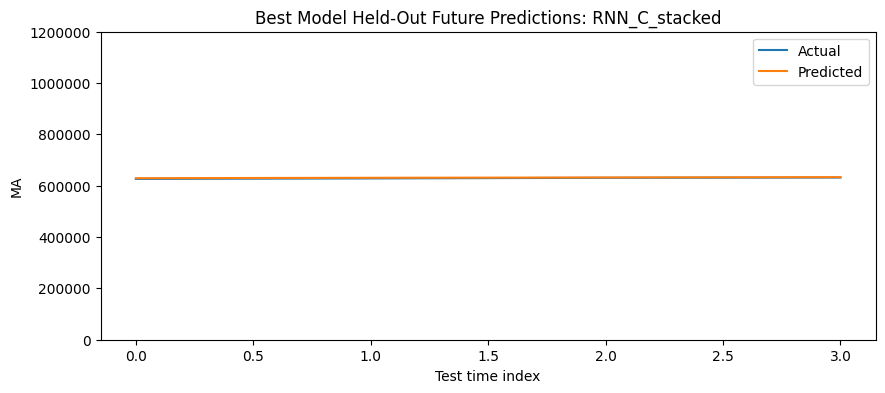

One-factor check (look_back only): A RMSE=6554.72 vs B RMSE=54923.81
Lower RMSE is better.


In [30]:
# Your code here
# Pick best model + simple model-behavior summary values for markdown write-up

best_model_name = subgroup_comparison.loc[0, "Model"]
best_run = rnn_runs[best_model_name]

print("Best model based on lowest Test RMSE:", best_model_name)
print(subgroup_comparison.loc[0])

# Plot best model predictions one more time for easy screenshot/use
best_test_pred = best_run["model"].predict(best_run["testX"])
best_test_pred_inv = scaler_sub.inverse_transform(best_test_pred)
best_testY_inv = scaler_sub.inverse_transform(best_run["testY"].reshape(-1, 1))

plt.figure(figsize=(10, 4))
plt.plot(best_testY_inv, label="Actual")
plt.plot(best_test_pred_inv, label="Predicted")
plt.title(f"Best Model Held-Out Future Predictions: {best_model_name}")
plt.xlabel("Test time index")
plt.ylabel("MA")
plt.ylim(0, 1200000)
plt.ticklabel_format(style="plain", axis="y")
plt.legend()
plt.show()

# one-factor-at-a-time comparison (A vs B only changes look_back)
a_rmse = subgroup_comparison.loc[subgroup_comparison["Model"] == "RNN_A_baseline", "Test_RMSE"].values[0]
b_rmse = subgroup_comparison.loc[subgroup_comparison["Model"] == "RNN_B_longer_window", "Test_RMSE"].values[0]

print(f"One-factor check (look_back only): A RMSE={a_rmse:.2f} vs B RMSE={b_rmse:.2f}")
print("Lower RMSE is better.")

For this exploration, I focused on the house, 3-bedroom subgroup and used a later time period (2010 onward) so I was modeling a different slice of the data than earlier sections. I tested three RNN configurations: (1) a baseline single-layer RNN with look_back=2, (2) a longer-window single-layer RNN with look_back=4 (one-factor-at-a-time change from the baseline), and (3) a stacked RNN with look_back=4, more units [32,16], and a slightly lower learning rate.

The one-factor test showed that changing only look_back from 2 to 4 worsened performance a lot in this setup (RMSE: 6554.72 -> 54923.81, MAE: 6534.73 -> 54901.86), so a longer window alone was not helpful here. However, the stacked/tuned version with the same look_back=4 improved performance the most (RMSE: 2113.33, MAE: 2033.09) and had the best validation metrics (Best val loss: 0.001292, Best val MAE: 0.02914). In the prediction plot, this model tracked the held-out future values much more closely than the other two models.

Based on RMSE, MAE, training/validation behavior, and the held-out prediction fit, RNN_C_stacked was the best model because it gave the lowest forecasting error by a clear margin and the most stable overall behavior.